# Machine Learning amb Python

Hi ha varis motius per triar Python con el llenguatge base per al Machine Learning: 
* És interpretat i d'alt nivell. Permet l'integració amb un Notebook de forma directa.
* És eficient perquè les biblioteques es poden fer en C/C++ o Fortran. 
* Permet operacions vectorials com altres llenguatges funcionals. Molt important per al Machine Learning. 
* És fàcil d'entendre, flexible, multiparadigma, similar a expressions matemàtiques.

Aquestes podrien ser algunes de les importacions típiques d'un projecte de Machine learning i els `alies` típics que trobarem en molts exemples:

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras 
```

Aquest notebook es pot executar en local, un servidor propi o en núvols com Google Colab o Kaggle. 

> Aquest notebook conté molts exemples de diverses tècniques que no sembre cal aplicar en tots els projectes. Aquestes són per preparar les dades i visualitzar-les. L'entrenament al detall de models el vorem en altres notebooks.

## Càrrega de dades

Anomenem `Dataset` al conjunt de dades, sovint tabular, que servirà per a entrenar els models de machine learning. Aquests solen estar en formats com `CSV`, `ARFF`, `Parquet`, encara que es poden llegir certs `JSON` i altres formats. 

Es pot llegir el CSV amb funcions estandard de Python i desprès crear el dataset, però `Pandas` ja té una funció per llegir i transformar en un tipo de dades anomenat `Dataframe`. 

Si el fitxer està al directori del notebook l'importarem amb:

In [38]:
import pandas as pd
import numpy as np
df = pd.read_csv("Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

No sempre serà tant fàcil. De vegades cal indicar coses com `sep` per si el separador no és la coma `','`. el paràmetre `decimal` per indicar un separador decimal. `names` per a indicar el nom de les columnes entre altres. Ací tenim el mateix exemple amb tots els paràmetres:

```python
df = pd.read_csv(
    'archivo.csv',
    sep=',',                # alias: delimiter
    delimiter=None,
    delim_whitespace=False,
    decimal='.',
    thousands=None,
    names=None,
    lineterminator=None,    
    skipinitialspace=False,
    na_values=None,
    keep_default_na=True,
    skiprows=None,
    skipfooter=0,
    nrows=None
)
```

Un Dataframe és com una matriu amb moltes propietats i funcions pròpies. És molt eficient i còmode en un Notebook. Per exemple, abans símplement hem posar la variable que el conté i s'ha imprés amb un format de tabla fàcil de llegir. 

Si el fitxer està a una URL es podria descarregar amb `!wget https://...` i desprès crear el `Dataframe` com abans. 

> Observa que posem ! per indicar que és un comandament del sistema. 

De totes formes és millor utilitzar directament `read_csv`:

In [2]:
# El dataset no té noms en les columnes i cal posar-los manualment
import pandas as pd
df = pd.read_csv(
"https://ocw.mit.edu/courses/15-097-prediction-machine-learning-and-statistics-spring-2012/89d88c5528513adc4002a1618ce2efb0_iris.csv" ,
names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
)
df

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
### Crear un dataset de múltiples fitxers

import pandas as pd

df_values = pd.read_csv(
"https://raw.githubusercontent.com/LeadingIndiaAI/Heart-Disease-Prediction-Using-Machine-Learning-Techniques/master/train_values.csv" )
df_labels = pd.read_csv(
"https://raw.githubusercontent.com/LeadingIndiaAI/Heart-Disease-Prediction-Using-Machine-Learning-Techniques/master/train_labels.csv" )
df = pd.merge(df_values, df_labels, on='patient_id')
df.drop(["patient_id"], axis=1, inplace=True) # Axis=1 per eliminar columnes i inplace per a muta el dataframe i no retornar una copia
    
df

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


## Atributs i mètodes de Pandas

Es poden consultar les dades que conté un Dataframe de varies maneres:

In [4]:
df.columns

Index(['slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='str')

In [5]:
df.dtypes

slope_of_peak_exercise_st_segment         int64
thal                                        str
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int64
exercise_induced_angina                   int64
heart_disease_present                     int64
dtype: object

In [6]:
df.shape  # Tupla

(180, 14)

In [7]:
df.values  # array bidimensional

array([[1, 'normal', 128, ..., 170, 0, 0],
       [2, 'normal', 110, ..., 158, 0, 0],
       [1, 'normal', 125, ..., 162, 1, 1],
       ...,
       [2, 'reversible_defect', 125, ..., 131, 1, 1],
       [1, 'normal', 124, ..., 175, 0, 0],
       [1, 'normal', 160, ..., 163, 0, 0]], shape=(180, 14), dtype=object)

In [8]:
df.head(5)

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [9]:
df.tail(5)

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    int64  
 1   thal                                  180 non-null    str    
 2   resting_blood_pressure                180 non-null    int64  
 3   chest_pain_type                       180 non-null    int64  
 4   num_major_vessels                     180 non-null    int64  
 5   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 6   resting_ekg_results                   180 non-null    int64  
 7   serum_cholesterol_mg_per_dl           180 non-null    int64  
 8   oldpeak_eq_st_depression              180 non-null    float64
 9   sex                                   180 non-null    int64  
 10  age                                   180 non-null    int64  
 11  max_heart_rate_achieved       

### Selecció de columnes

En moltes ocasions ens interessen unes poques columnes d'un Dataframe:

In [11]:
df[["thal"]]

,thal
0,normal
1,normal
2,normal
3,reversible_defect
4,reversible_defect
...,...
175,reversible_defect
176,normal
177,reversible_defect
178,normal


In [12]:
df[["thal","age"]]

,thal,age
0,normal,45
1,normal,54
2,normal,77
3,reversible_defect,40
4,reversible_defect,59
...,...,...
175,reversible_defect,67
176,normal,55
177,reversible_defect,64
178,normal,48


In [13]:
df.drop(["age"], axis=1)  # Per eliminar una columna. Podem posar inplace=True si volem mutar el df original

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,normal,128,2,0,0,2,308,0.0,1,170,0,0
1,2,normal,110,3,0,0,0,214,1.6,0,158,0,0
2,1,normal,125,4,3,0,2,304,0.0,1,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,1,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,reversible_defect,125,4,2,1,0,254,0.2,1,163,0,1
176,2,normal,180,4,0,0,1,327,3.4,0,117,1,1
177,2,reversible_defect,125,3,0,0,0,309,1.8,1,131,1,1
178,1,normal,124,3,2,1,0,255,0.0,1,175,0,0


## Anàlisi de les dades

Amb les funcions i atributs anteriors es veu cóm fer un primer anàlisi de les dades. Cal entendre el problema, el significat dels atributs i els tipus de dades. 

Aquest anàlisi permet posteriorment eliminar columnes o files innecesàries o problemàtiques, corregir algunes dades, normalitzar, entre altres. 

Si en etapes prèvies s'h fet un bon treball, tindrem un dataset documentat i net. Això no vol dir que siga dirèctament vàlid per entrenar. Per veure què podem millorar de cara a fer un model, primer llegirem la documentació. 

> Un primer anàlisi es pot fer en una fulla de càlcul. No cal reinventar la roda i és una ferramenta molt potent i visual. 



In [65]:
#descomentar la primera vegada !wget https://archive.ics.uci.edu/static/public/45/heart+disease.zip
#descomentar la primera vegada !unzip heart+disease.zip
df = pd.read_csv('processed.cleveland.data',
names=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang',
'oldpeak', 'slope', 'ca', 'thal', 'num']
)

In [66]:
df.info()  # Es pot fer shape, columns, dtypes

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [42]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### Detecció de valors no numèrics

Anteriorment hem vist que totes les columes semblen numèriques excepte 2. Si fem un `head` semblen numèriques. La documentació ens indica que poden faltar dades, així que anem a detectar valors no numèrics en `ca`:

In [67]:
df[pd.to_numeric(df.ca, errors="coerce").isna()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,?,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,?,7.0,1
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,?,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0


Pareix senzill, però encara no haviem vist aquest tipus d'expressions en un Dataframe. 

Veiem què donen les expressions de dins:

In [68]:
print("ca: \n",df.ca,"\n to_numeric: \n",pd.to_numeric(df.ca, errors="coerce"),"\n isna: \n", pd.to_numeric(df.ca, errors="coerce").isna())


ca: 
 0      0.0
1      3.0
2      2.0
3      0.0
4      0.0
      ... 
298    0.0
299    2.0
300    1.0
301    1.0
302      ?
Name: ca, Length: 303, dtype: str 
 to_numeric: 
 0      0.0
1      3.0
2      2.0
3      0.0
4      0.0
      ... 
298    0.0
299    2.0
300    1.0
301    1.0
302    NaN
Name: ca, Length: 303, dtype: float64 
 isna: 
 0      False
1      False
2      False
3      False
4      False
       ...  
298    False
299    False
300    False
301    False
302     True
Name: ca, Length: 303, dtype: bool


La funció `to_numeric` amb `coerce` intenta transformar a números i si falla dona `NaN`. Aquesta funció accepta un dataframe i el transforma sencer. El resultat es pot transformar a un altre Dataframe de vertader o fals amb `.isna()`. El resultat és una llista de `True` `False` de la mateixa longitut i posicions que el Dataframe original. En aquest cas es passa la llista com a filtre del Dataframe original. 

In [69]:
df[pd.to_numeric(df.ca, errors='coerce').isna() | pd.to_numeric(df.thal, errors='coerce').isna()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,?,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,?,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,?,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,?,2
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,?,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0


El que detectem és que gasten `?` per indicar que és nul. Així que es podria llegir dirèctament amb el `read_csv` i `na_values`:

```python
df = pd.read_csv('processed.cleveland.data',
names=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang',
'oldpeak', 'slope', 'ca', 'thal', 'num'],
na_values = '?'
)
```

Per a convertir els valores en nuls:


In [70]:
df.ca = pd.to_numeric(df.ca, errors='coerce')
df.thal = pd.to_numeric(df.thal, errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


Es poden detectar NaN amb `isna()`, nuls amb `isnull()` o valors determinats amb `isin(valors)`:



In [71]:

100 * df.isna().sum()/df.shape[0]

age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.000000
chol        0.000000
fbs         0.000000
restecg     0.000000
thalach     0.000000
exang       0.000000
oldpeak     0.000000
slope       0.000000
ca          1.320132
thal        0.660066
num         0.000000
dtype: float64

In [72]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [73]:
total = df.isna().sum().sort_values(ascending=False)
percent_1 = df.isna().sum()/df.shape[0]*100
percent_2 = (round(percent_1, 1)).sort_values(ascending=False)
missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
missing_data[missing_data['%'] != 0]

,Total,%
ca,4,1.3
thal,2,0.7


L'anterior anàlisi ho mostra de manera més concisa i utilitza `pd.concat()` que crea un Dataframe d'un array i indica les columnes. 

Per eliminar els valors nuls tenim varies opcions:

1: Eliminar les files que els contenen. La solució més sencilla, però massa dràstica perquè es perden dades:

```python
df.dropna(subset=['ca'], inplace=True)
```

Si posem `inplace=False` es veu cóm queda sense necessitat de esborrar definitivament.

Inclús si volem eliminar totes les files amb NaN:
```python
df.dropna(inplace=True)
```

2 Eliminar atributs o columnes: Pot ser més perillosa encara, però els atributs que tenen massa valors nuls pot ser no aporten informació útil. 
```python
df.drop(['ca'], axis=1, inplace=True)
```

No s'ha d'eliminar sempre, cal valorar el perquè són nulls i decidir si eliminar o sustituir. 

3: Sustituir el valor per un atlre representatiu. Es pot canviar per la mitjana:


In [74]:
df['ca'] = df['ca'].fillna(df['ca'].mean())

Es pot sustituir per 0, per exemple:

In [75]:
df['thal'] = df['thal'].fillna(0)

### Adaptació del `target` 

Hem vist que el atribut `num`, que és el target a predir, és de tipus `int64`. Per a un problema de classificació els transformarem a `categoric`:

In [76]:
df['num']=pd.Categorical(df['num'])

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    float64 
 1   sex       303 non-null    float64 
 2   cp        303 non-null    float64 
 3   trestbps  303 non-null    float64 
 4   chol      303 non-null    float64 
 5   fbs       303 non-null    float64 
 6   restecg   303 non-null    float64 
 7   thalach   303 non-null    float64 
 8   exang     303 non-null    float64 
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    float64 
 11  ca        303 non-null    float64 
 12  thal      303 non-null    float64 
 13  num       303 non-null    category
dtypes: category(1), float64(13)
memory usage: 31.2 KB


### Anàlisi de la distribució de freqüències

Analitzant les freqüències de les dades veurem si un atribut en principi numèric és pot considerar categòric o al contrari.

In [78]:
df['num'].value_counts().sort_index()

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

<Axes: xlabel='num'>

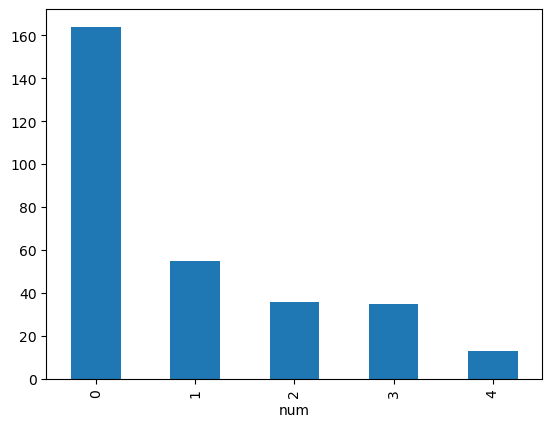

In [79]:
df['num'].value_counts().sort_index().plot(kind='bar')

Es pot veure que hi ha molts 0 i altres 1,2,3,4. En realitat per a la predicció necessitem sols si és 0 o més, així que deguem transformar la columna:

In [80]:
#df['num'] = df['num'].map({0:0, 1:1, 2:1, 3:1, 4:1})
df['num'] = df['num'].map(lambda x: 1 if (x > 0) else 0)

Els dos exemples anteriors transformen valors majors que 1 a 1. La primera utilitza un diccionari de sustitucions aplicar a la funció `map()`. La segona una funció `lambda`. En qualsevol cas són tècniques de programació funcional. 

num
0    54.125413
1    45.874587
Name: count, dtype: float64


<Axes: xlabel='num'>

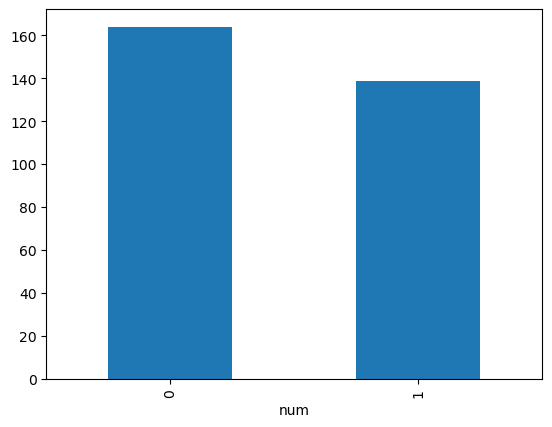

In [81]:
print(100 * df['num'].value_counts()/df.shape[0])
df['num'].value_counts().sort_index().plot(kind='bar')


Ara ja es veu que tenim un dataset prou equilibrat en 0s i 1s. 

Ara poden treure l'**Histograma** dels valors numèrics:

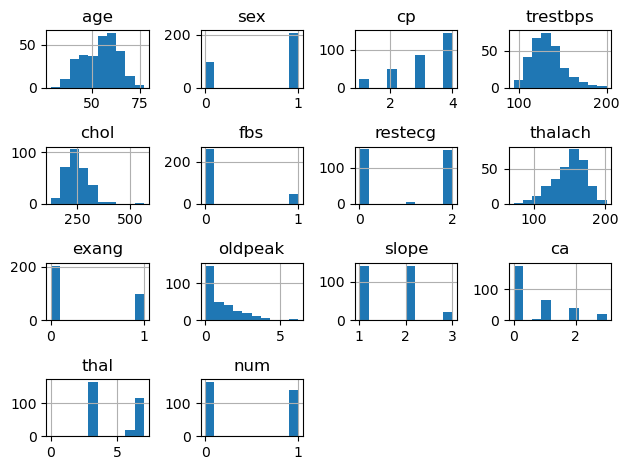

In [82]:
import matplotlib.pyplot as plt
df.hist()
plt.tight_layout () # per a que no es solapen els gràfics

Els histogrames mostren que els atributs numérics reals tenen una distribució aproximadament normal:

* age: Prou normal, encara que podria ser bimodal.
* chol: normal
* trestbps, thalach: Normal inclinada
* olpeak: normal molt inclinada

Altres atributs no tenen normal o tenen sols dos o tres valors possibles. 

* sex: Dicotòmic 
* cp: Té 4 valors distints, pareix normal, però la documentació diu que és categòrica. Això vol dir que pot ser que 4 no signifique "més" que els altres en algún sentit.  (és important llegir la documentació). Es tracta del tipus de dolor en el pit i 4 no siginfica més dolor, és un altre tipus.
* fbs: Dicotòmic
* restecg: Categòric de 3 valors.
* ca: És categòrica segons la documentació amb 0,1,2,3 com a possibles valors. 
...




(array([ 1.,  0.,  0.,  0.,  2.,  4.,  2.,  2.,  4.,  3., 18.,  8., 11.,
         8.,  7., 12.,  5.,  7., 12., 13., 24.,  8., 11., 17., 19., 26.,
         8., 11.,  9., 10., 15.,  9.,  4.,  3.,  4.,  3.,  0.,  1.,  0.,
         2.]),
 array([29. , 30.2, 31.4, 32.6, 33.8, 35. , 36.2, 37.4, 38.6, 39.8, 41. ,
        42.2, 43.4, 44.6, 45.8, 47. , 48.2, 49.4, 50.6, 51.8, 53. , 54.2,
        55.4, 56.6, 57.8, 59. , 60.2, 61.4, 62.6, 63.8, 65. , 66.2, 67.4,
        68.6, 69.8, 71. , 72.2, 73.4, 74.6, 75.8, 77. ]),
 <BarContainer object of 40 artists>)

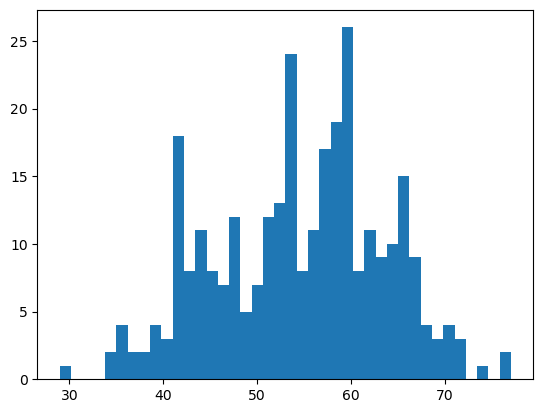

In [83]:
#df.hist(['age'], bins=40)
plt.hist(df['age'], bins=40)

Ara podem analitzar en detall determinats valors per veure com es comporten en bins més menuts

(array([0.00330033, 0.0330033 , 0.10891089, 0.12541254, 0.12211221,
        0.1980198 , 0.21122112, 0.14191419, 0.04620462, 0.00990099]),
 array([29. , 33.8, 38.6, 43.4, 48.2, 53. , 57.8, 62.6, 67.4, 72.2, 77. ]),
 <BarContainer object of 10 artists>)

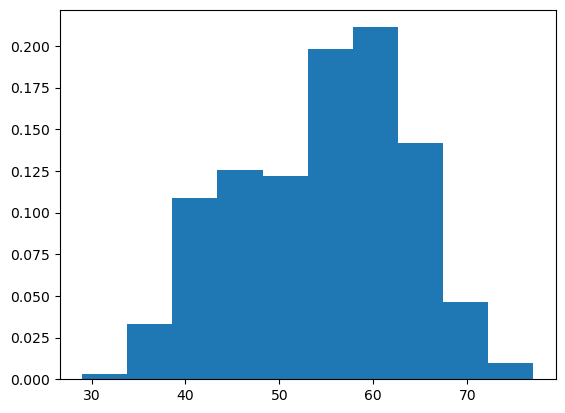

In [84]:
plt.hist(df['age'], weights=np.ones_like(df['age'])/ df.shape[0])

Com que moltes variables són en realitat dicotòmiques o categòriques es pot canviar el seu tipus. 

In [85]:
df['sex']=pd.Categorical(df['sex'])
df['cp']=pd.Categorical(df['cp'])
df['fbs']=pd.Categorical(df['fbs'])
df['restecg']=pd.Categorical(df['restecg'])
df['exang']=pd.Categorical(df['exang'])
df['slope']=pd.Categorical(df['slope'])
df['thal']=pd.Categorical(df['thal'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    float64 
 1   sex       303 non-null    category
 2   cp        303 non-null    category
 3   trestbps  303 non-null    float64 
 4   chol      303 non-null    float64 
 5   fbs       303 non-null    category
 6   restecg   303 non-null    category
 7   thalach   303 non-null    float64 
 8   exang     303 non-null    category
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    category
 11  ca        303 non-null    float64 
 12  thal      303 non-null    category
 13  num       303 non-null    int64   
dtypes: category(7), float64(6), int64(1)
memory usage: 18.9 KB


### One-hot Encoding

En cas de voler fer un algorisme de regressió, aquest sols accepta atributs numèrics. Els atributs categòrics que són rellevants s'han de codificar com a numèrics. 

Hi ha un problema amb posar números als atributs categòrics. Si fem `Label encoding` que és assignar un número a cada categoria, li donarem un significat diferent al que volem. 

Suposem el cas d'una regressió lineal amb dos variables. L'equació resultant serà: 

En el cas d'una regressió lineal amb dues variables independents (també coneguda com a **regressió lineal múltiple** amb dues variables predictoras), l'equació que defineix la relació entre les variables és la següent:

$$Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \epsilon$$

---

Desglossament dels components:

* **$Y$**: És la **variable dependent** (o variable de resposta), que és el valor que volem predir o explicar.
* **$X_1$ i $X_2$**: Són les **variables independents** (o variables explicatives/predictoras).
* **$\beta_0$**: És la **intercepció** (o terme constant). Representa el valor esperat de $Y$ quan tant $X_1$ com $X_2$ són iguals a zero.
* **$\beta_1$ i $\beta_2$**: Són els **coeficients de regressió** (o pendents parcials). Indiquen quant canvia $Y$ per cada unitat que augmenta la variable corresponent ($X_1$ o $X_2$), mantenint l'altra variable constant.
* **$\epsilon$**: És el **terme d'error** (o residu). Representa la variabilitat en $Y$ que no pot ser explicada pel model lineal amb les variables donades.

A diferència d'una regressió lineal simple (on la representació és una línia recta en un pla 2D), aquesta equació representa un **pla en un espai tridimensional**.

Si tenim una variable, per exemple, *marca*  en un dataset de cotxes per predir el preu, si són 5 marques tindrem `[0,1,2,3,4]` o `[1,2,3,4,5]` o `[-1, -0.5, 0, 0.5, 1]`. En qualsevol cas tenim números que acabaran afectant a un $\beta$ i multiplicats per un X i el seu valor més alt o baix influirà numèricament encara que siga una variable categòrica que no implica un valor més alt o més baix. 

La solució és fer `One-hot encoding` al crear una columa dicotòmica amb 0 o 1 per cada categoria. D'aquesta manera per a 5 marques es poden fer 5 columnes, una per marca indicant amb un 1 si és eixa marca. El model aprendrà a asignar una  $\beta$ determinada a marques generalment mès valuoses sense afectar a la resta del model. 

Una millor manera és fer `Variables Dummy` llevant una columna. A 5 marques 4 columnes, una per marca i si és 0 la marca que falta (la marca per defecte). Això evita una correlació perfecta entre eixes columnes que, si no, sempre sumen 1 i crea una dependència lineal que empijora el model. 

https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html

Anem a fer `One-hot encoding` al dataset del cor: 


In [86]:
df_backup = df.copy()

In [93]:
df_onehot = pd.get_dummies(df_backup, columns=['sex','cp','fbs','restecg','exang','slope','thal'], prefix=['sex','cp','fbs','restecg','exang','slope','thal'], prefix_sep='_' , drop_first=True)

In [94]:
df_onehot

,age,trestbps,chol,thalach,oldpeak,ca,num,sex_1.0,cp_2.0,cp_3.0,cp_4.0,fbs_1.0,restecg_1.0,restecg_2.0,exang_1.0,slope_2.0,slope_3.0,thal_3.0,thal_6.0,thal_7.0
0,63.0,145.0,233.0,150.0,2.3,0.000000,0,True,False,False,False,True,False,True,False,False,True,False,True,False
1,67.0,160.0,286.0,108.0,1.5,3.000000,1,True,False,False,True,False,False,True,True,True,False,True,False,False
2,67.0,120.0,229.0,129.0,2.6,2.000000,1,True,False,False,True,False,False,True,True,True,False,False,False,True
3,37.0,130.0,250.0,187.0,3.5,0.000000,0,True,False,True,False,False,False,False,False,False,True,True,False,False
4,41.0,130.0,204.0,172.0,1.4,0.000000,0,False,True,False,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,110.0,264.0,132.0,1.2,0.000000,1,True,False,False,False,False,False,False,False,True,False,False,False,True
299,68.0,144.0,193.0,141.0,3.4,2.000000,1,True,False,False,True,True,False,False,False,True,False,False,False,True
300,57.0,130.0,131.0,115.0,1.2,1.000000,1,True,False,False,True,False,False,False,True,True,False,False,False,True
301,57.0,130.0,236.0,174.0,0.0,1.000000,1,False,True,False,False,False,False,True,False,True,False,True,False,False


Si no posem dtype=int ix True/False, però funcionarà bé encara que no siga 0/1

### Correlacions entre atributs

Existeix correlació entre dos atributs quan l'augment dels valors d'un conlleva l'augment del
valor de otro (correlación positiva) o la seva disminución (correlación negativa).

Per exemple, hi ha correlació positiva entre l'alçada de les persones i el seu pes. Per terme mitjà, les
persones pesan més quant més altes son. Hi ha correlació negativa entre el nombre d'anys d'escolarització -
ción de las personas y el número de faltas de ortografía que cometen.
Interesa estudiar correlacions entre atributs, pels següents motius:
* Es pot obtindre un model més sencill eliminant atributs que no proporcionen molta informació amb respecte a altres. Esto pot suposar una merma en la qualitat del model, que habrà que valorar.
* Per a models de regresió, interessa especialment els atributs predictors que tenen major correlació amb l'atribut target u objectiu.
* Per a models de regressió, pot ser perjudicial tenir atributs predictors que presenten

Veiem el `gràfic de parell de punts` que ens dona dirèctament `seaborn`:

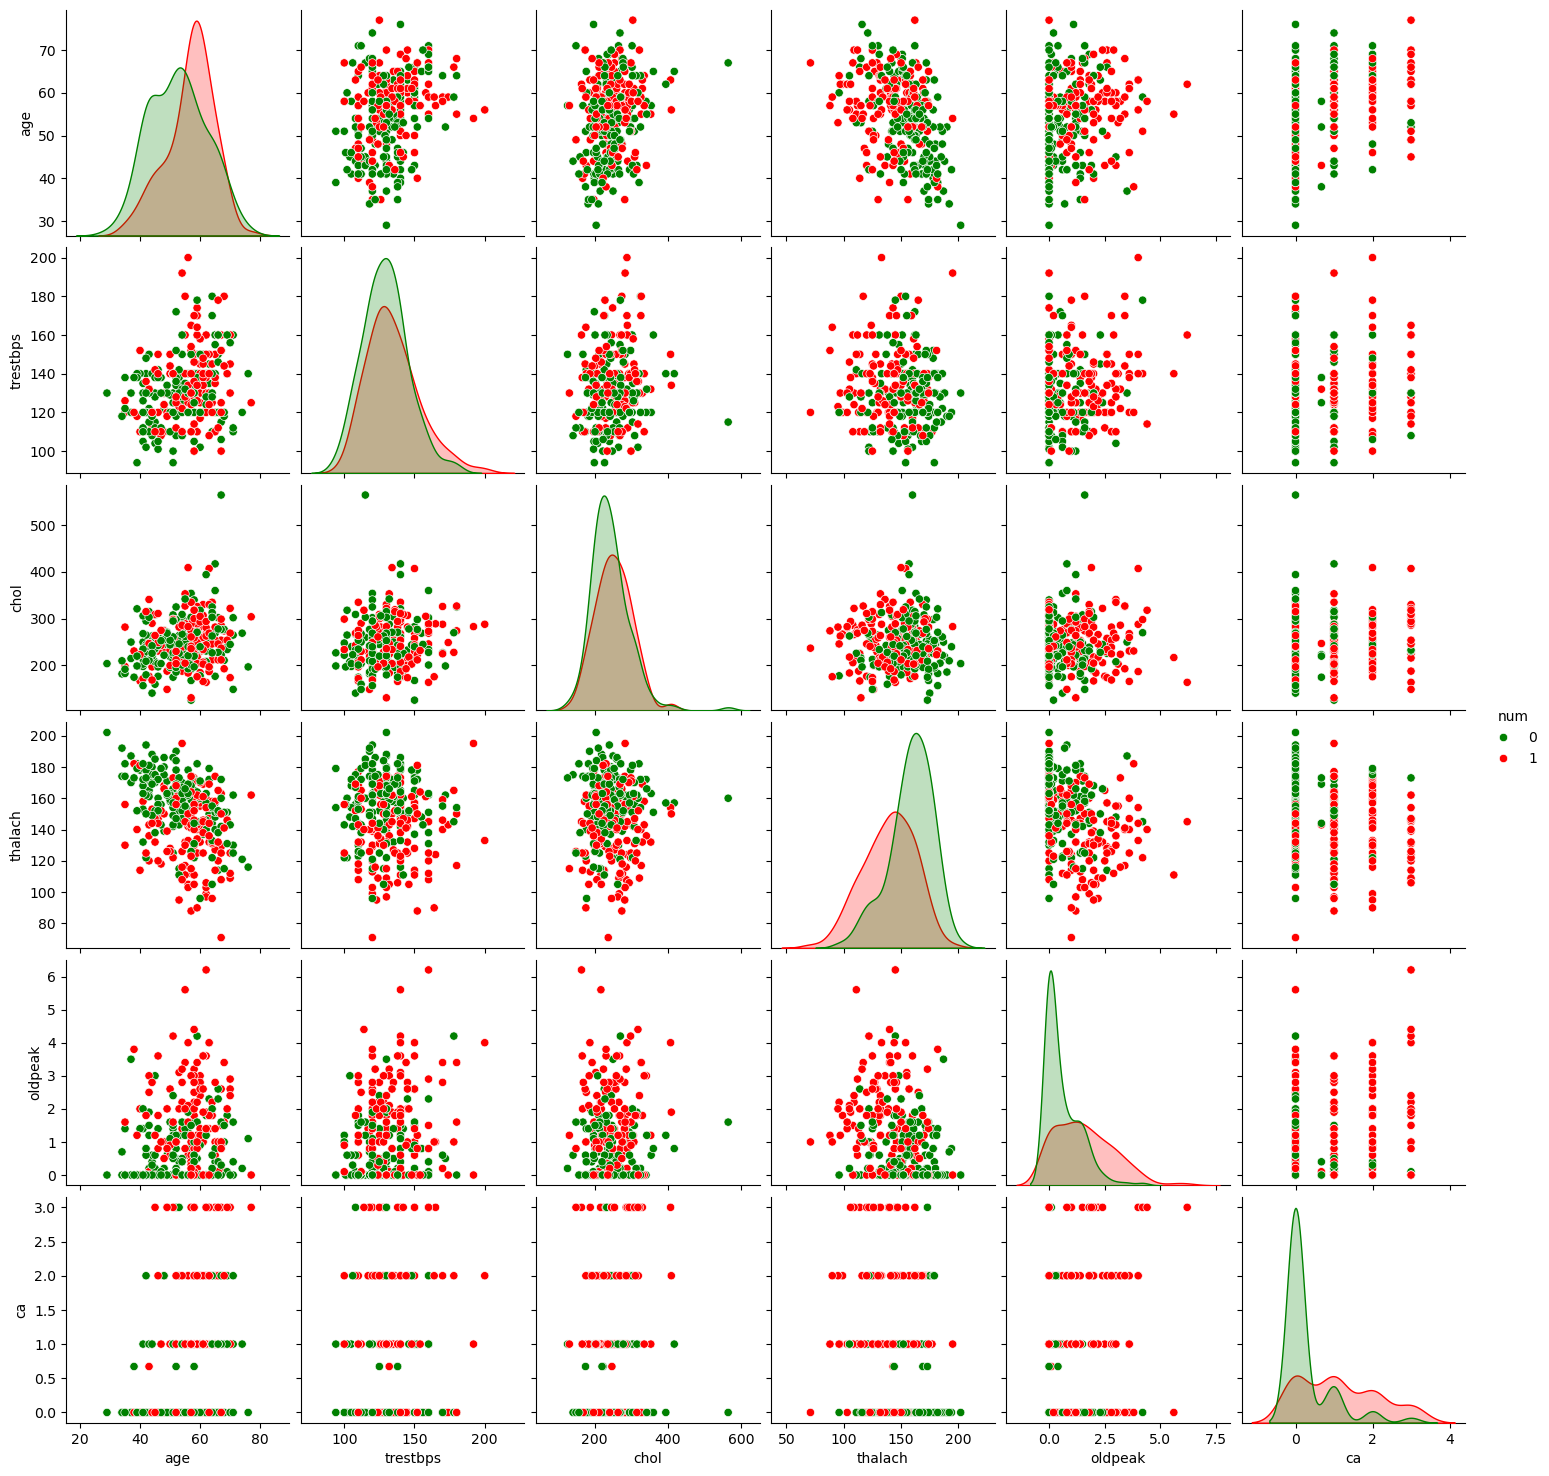

In [95]:
import seaborn as sns
df = df_backup.copy()
sns.pairplot(data=df, hue='num', palette={0:'green', 1:'red'})

El gràfic en aquest cas no és especialment informatiu entre variables. No s'aprecien correlacions significatives, formen `blobs` i no línies. Això no vol dir que no siga útil en algunes i 


Els gràfics de dalt són igual que els de baix amb simetria respete la visectriz. Amb `corner=True` es mostren sols els de baix. 

Aquest gràfic és molt costós computacionalment. Amés és subjectiu. Així que poden buscar alternatives. 

Calcularem el `Coeficient de correlació lineal`. Això és una medida quantitativa de la correlació lineal entre atributs. Els seus valors van de -1 a 1. En 0 no hi ha cap correlació. 



<Axes: >

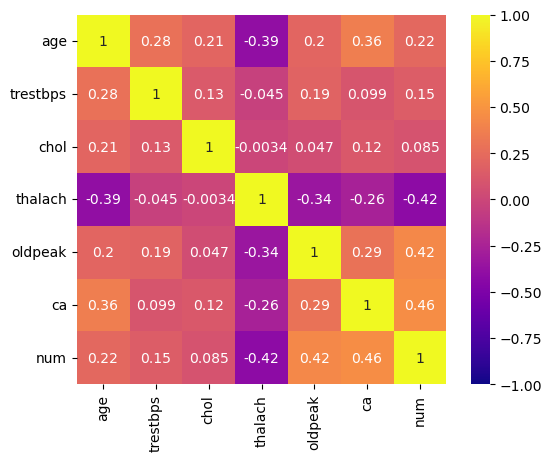

In [100]:
# 1. Separar columnes numèriques (incloses les dummies)
df_num = df.select_dtypes(include=['int64', 'float64', 'uint8'])

# 2. Calcular la correlació només sobre aquestes
corr_matrix = df_num.corr()

# 3. Dibuixar el heatmap
sns.heatmap(corr_matrix, square=True, annot=True, vmin=-1, vmax=1, cmap='plasma')

> Per veure més esquemes de colors possibles: https://matplotlib.org/stable/tutorials/colors/colormaps.html 

Una alternativa sols amb la part inferior, imatge més gran, 5 decimals, evitar notació cientìfica. 

<Axes: >

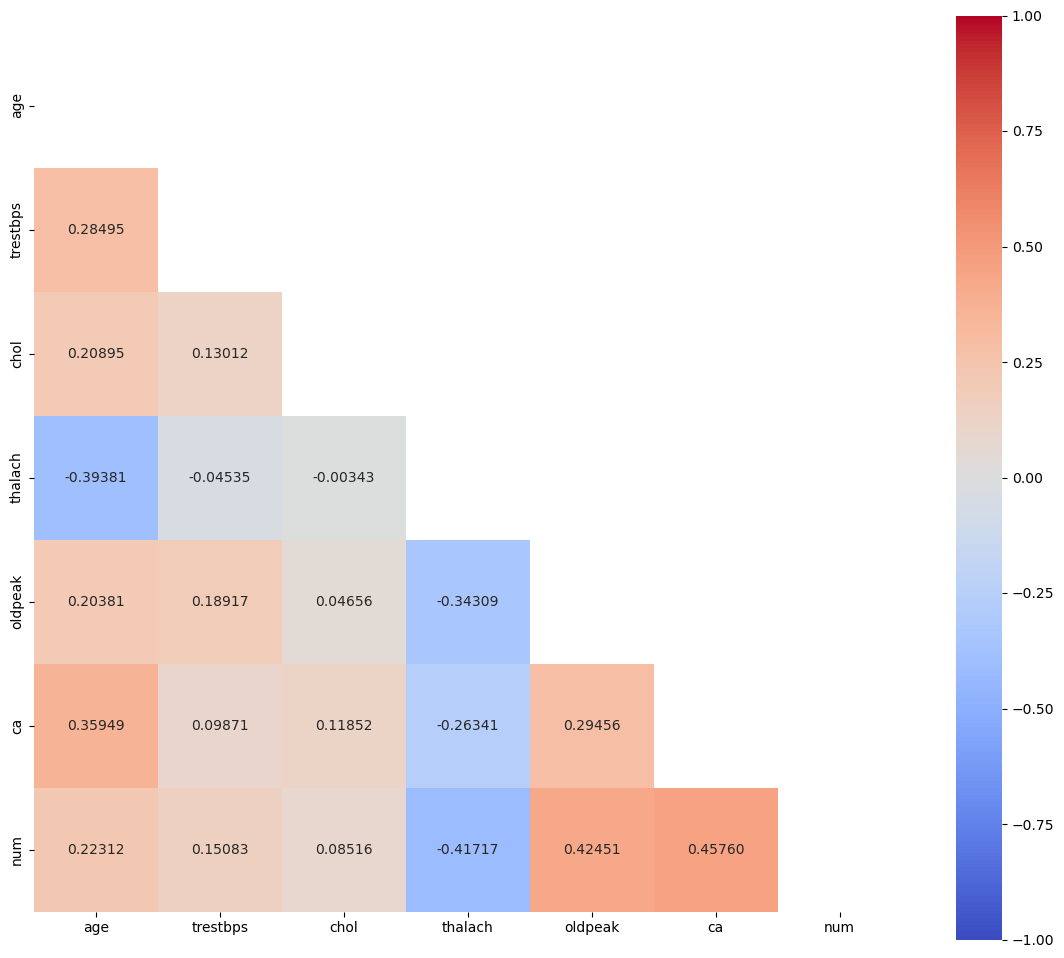

In [101]:
corr = df_num.corr()
mask = np.triu(corr)
plt.figure(figsize=(14,12))
sns.heatmap(corr, square=True, annot=True, vmin=-1, vmax=1, cmap='coolwarm',
mask=mask, fmt = '.5f')

<Axes: >

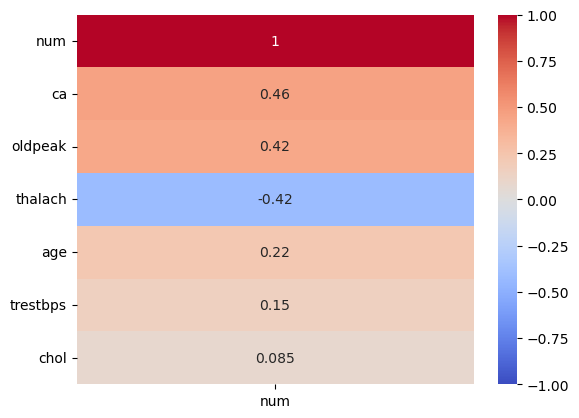

In [102]:
corr = df_num.corr()[['num']]
sns.heatmap(corr.iloc[(-corr['num'].abs()).argsort()], vmin=-1, vmax=1,
annot=True, cmap='coolwarm')

Aquesta última alternativa demostra les variables amb més correlació absoluta amb num. 

## Gràfics

Podem pintar en `matplotlib` quasevol funció:


Text(0, 0.5, 'y')

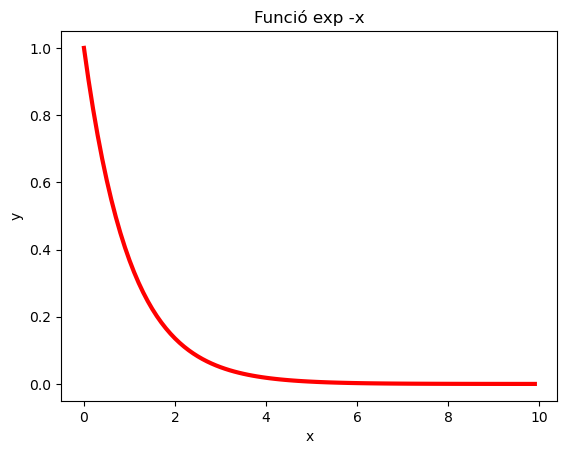

In [104]:
x = np.arange(0, 10, 0.1)
plt.plot(x, np.exp(-x), color="red", linewidth=3)
plt.title('Funció exp -x')
plt.xlabel('x')
plt.ylabel('y')

Text(0, 0.5, 'y')

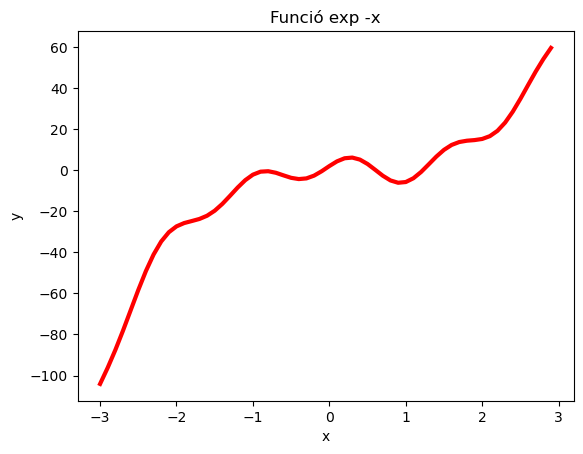

In [108]:
np.random.seed(42)  # Fixar una llavor per a la reproductibilitat
X = np.arange(-3, 3, 0.1)  # Generar valors uniformes entre -3 i 3
plt.plot(X, 3 * X**3 - 2 * X**2 + 5 * np.sin(5 * X) + 2 * np.cos(3 * X), color="red", linewidth=3)
plt.title('Funció exp -x')
plt.xlabel('x')
plt.ylabel('y')

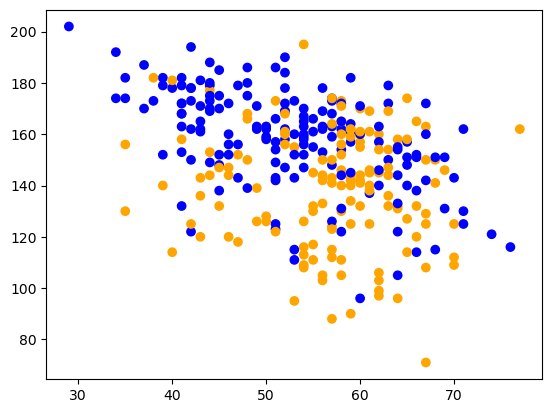

In [113]:
df.dropna(inplace=True)
plt.scatter(df['age'], df['thalach'], c=df['num'].map({0:'blue',1:'orange'}))

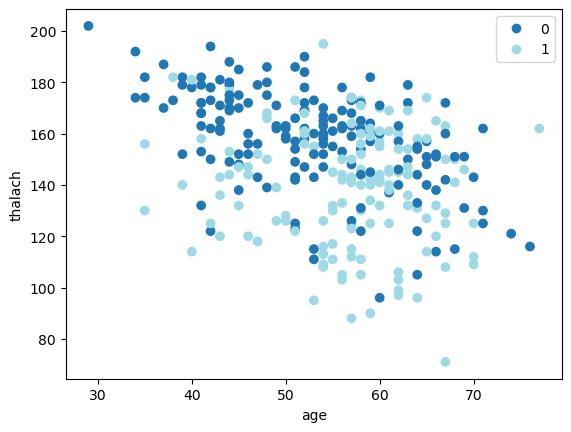

In [114]:
from sklearn.preprocessing import LabelEncoder
attr_x = 'age'
attr_y = 'thalach'
attr_target = 'num'
plt.xlabel(attr_x)
plt.ylabel(attr_y)
le = LabelEncoder()
le.fit(df[attr_target])
scatter = plt.scatter(df[attr_x], df[attr_y],
c=le.transform(df[attr_target]), cmap='tab20')
plt.legend(handles=scatter.legend_elements()[0],
labels=list(le.classes_))

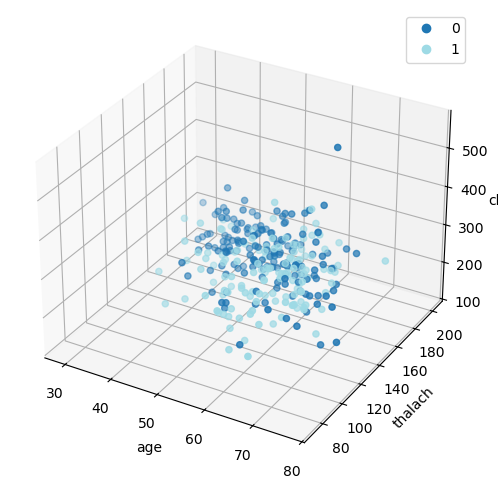

In [115]:
from sklearn.preprocessing import LabelEncoder
attr_x = 'age'
attr_y = 'thalach'
attr_z = 'chol'
attr_target = 'num'
ax = plt.figure().add_subplot(projection = '3d')
plt.gcf().set_size_inches(8, 6)
ax.set_xlabel(attr_x)
ax.set_ylabel(attr_y)
ax.set_zlabel(attr_z)
le = LabelEncoder()
le.fit(df[attr_target])
scatter = ax.scatter(df[attr_x], df[attr_y], df[attr_z],c=le.transform(df[attr_target]), cmap='tab20')
plt.legend(handles=scatter.legend_elements()[0],
labels=list(le.classes_))